<a href="https://colab.research.google.com/github/SOFIA-SHANMUGAM/Code/blob/main/Sentiment_Anlaysis_RoBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.580655,0.580128,0.743500,0.746137,0.743500,0.743479
2,0.506926,0.611889,0.753000,0.753814,0.753000,0.749646
3,0.366628,0.670206,0.751000,0.752197,0.751000,0.750059


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.73      0.74      3972
     Neutral       0.73      0.73      0.73      5937
    Positive       0.71      0.72      0.71      2375

    accuracy                           0.73     12284
   macro avg       0.72      0.73      0.73     12284
weighted avg       0.73      0.73      0.73     12284



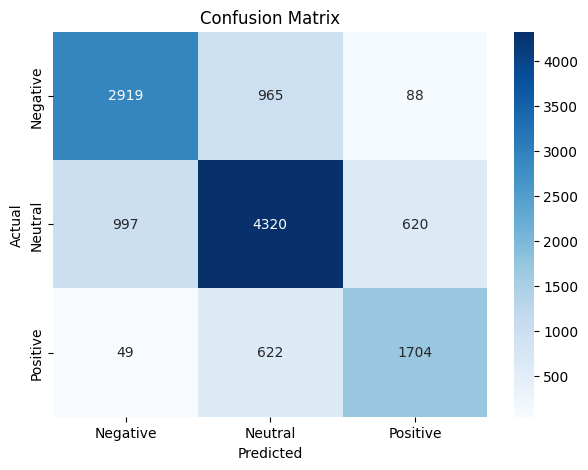

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!
Positive
Neutral
Negative


In [ ]:
!pip install -q transformers datasets evaluate scikit-learn matplotlib seaborn

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

train_ds = dataset["train"]
val_ds   = dataset["validation"]
test_ds  = dataset["test"]

print(dataset)

model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=True,
        max_length=128
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

cols = ["input_ids", "attention_mask", "label"]

train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label={0:"Negative",1:"Neutral",2:"Positive"},
    label2id={"Negative":0,"Neutral":1,"Positive":2}
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

training_args = TrainingArguments(
    output_dir="/content/roberta_sentiment_output",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    disable_tqdm=False,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

predictions = trainer.predict(test_ds)

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative","Neutral","Positive"]
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

save_path = "/content/final_roberta_tweeteval"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved successfully!")

def predict_sentiment(text):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()

    labels = {
        0:"Negative",
        1:"Neutral",
        2:"Positive"
    }

    return labels[pred]

print(predict_sentiment("I love this product so much!"))
print(predict_sentiment("It is average, nothing special."))
print(predict_sentiment("Worst experience ever."))